 visualize the embedding vectors using Matplotlib and t-SNE (a dimensionality reduction technique) to understand how similar vectors cluster together.

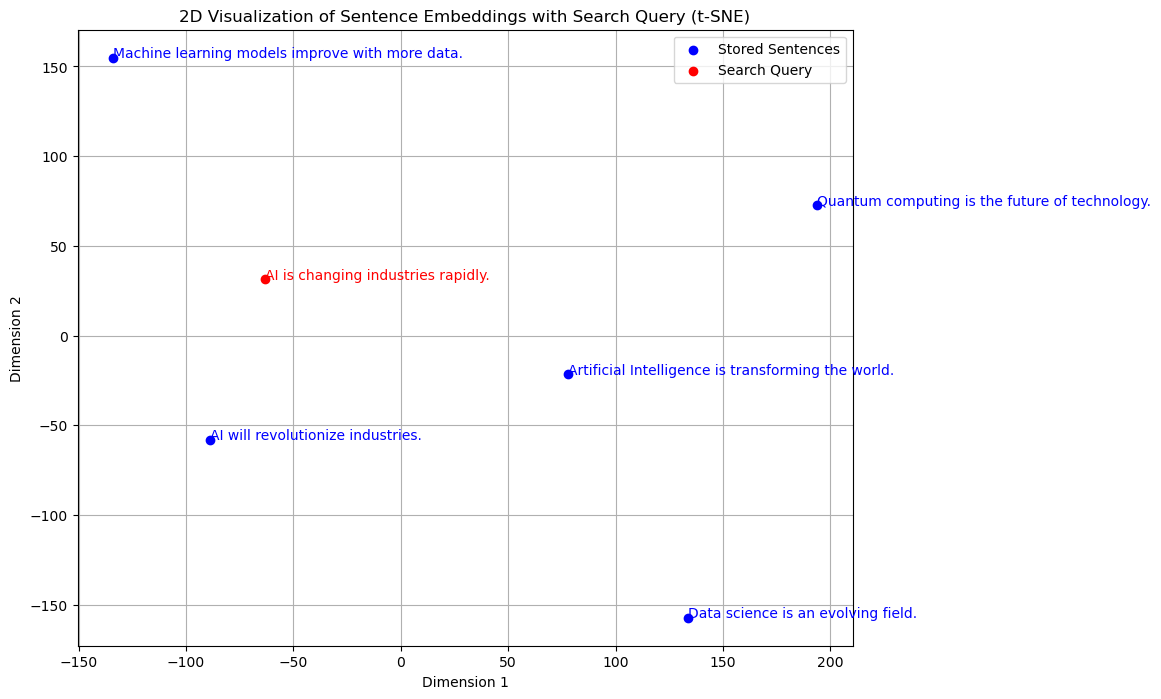

In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Original sentences
sentences = [
    "Artificial Intelligence is transforming the world.",
    "Machine learning models improve with more data.",
    "Quantum computing is the future of technology.",
    "AI will revolutionize industries.",
    "Data science is an evolving field."
]

# Generate embeddings
embeddings = model.encode(sentences, convert_to_numpy=True)

# Add a search query
query = "AI is changing industries rapidly."
query_embedding = model.encode([query], convert_to_numpy=True)

# Combine embeddings
all_embeddings = np.vstack([embeddings, query_embedding])
all_sentences = sentences + [query]

# Reduce dimensions with a smaller perplexity
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
reduced_embeddings = tsne.fit_transform(all_embeddings)

# Plotting the embeddings
plt.figure(figsize=(10, 8))

# Plot stored sentences
plt.scatter(reduced_embeddings[:-1, 0], reduced_embeddings[:-1, 1], color='blue', label='Stored Sentences')

# Plot the query sentence
plt.scatter(reduced_embeddings[-1, 0], reduced_embeddings[-1, 1], color='red', label='Search Query')

# Annotate each point
for i, sentence in enumerate(all_sentences):
    color = 'red' if i == len(all_sentences) - 1 else 'blue'
    plt.annotate(sentence, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), color=color)

plt.title("2D Visualization of Sentence Embeddings with Search Query (t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()
